# CREDIT CARD FRAUD DETECTION

In [1]:
import pandas as pd 
import janitor

# Load both files
fraud_train = pd.read_csv('C:/Users/USER/Downloads/archive/fraudTrain.csv')
fraud_test  = pd.read_csv('C:/Users/USER/Downloads/archive/fraudTest.csv')

print(fraud_train.head(10))
print(fraud_test.head(10))


   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   
5           5   2019-01-01 00:04:08  4767265376804500   
6           6   2019-01-01 00:04:42    30074693890476   
7           7   2019-01-01 00:05:08  6011360759745864   
8           8   2019-01-01 00:05:18  4922710831011201   
9           9   2019-01-01 00:06:01  2720830304681674   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy 

In [2]:
# Check shapes before joining
print(f'Train shape: {fraud_train.shape}')
print(f'Test shape:  {fraud_test.shape}')


Train shape: (1296675, 23)
Test shape:  (555719, 23)


In [3]:
# checking for duplicates
fraud_train.duplicated().sum()
fraud_test.duplicated().sum()

np.int64(0)

In [4]:
# data cleaning
fraud_train.columns
fraud_test.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [5]:
# Convert string to datetime objects
# first Rename the dataframe
ft = fraud_train
fte = fraud_test

ft['trans_date_trans_time'] = pd.to_datetime(ft['trans_date_trans_time'])

# Extract time-based features that help models detect anomalies
ft['hour'] = ft['trans_date_trans_time'].dt.hour
ft['day_of_week'] = ft['trans_date_trans_time'].dt.dayofweek
ft['month'] = ft['trans_date_trans_time'].dt.month
ft['year'] = ft['trans_date_trans_time'].dt.year

# let us do the same for the test data
fte['trans_date_trans_time'] = pd.to_datetime(fte['trans_date_trans_time'])

# Extract time-based features that help models detect anomalies
fte['hour'] = fte['trans_date_trans_time'].dt.hour
fte['day_of_week'] = fte['trans_date_trans_time'].dt.dayofweek
fte['month'] = fte['trans_date_trans_time'].dt.month
fte['year'] = fte['trans_date_trans_time'].dt.year

In [6]:
# Drop identifiers that don't provide predictive value
cols_to_drop = ['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'trans_num', 'unix_time']
ft = ft.drop(columns=cols_to_drop)
cols_to_drop = ['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'trans_num', 'unix_time']
fte = fte.drop(columns=cols_to_drop)

In [7]:
ft2 = ft.clean_names()
ft2 = ft2.remove_empty() # Removes any completely empty rows/columns
ft2 = ft2.rename(columns={'trans_date_trans_time': 'date'}) # rename this column as date
ft2.head(6)

# now for the test data
fte2 = fte.clean_names()
fte2 = fte2.remove_empty() # Removes any completely empty rows/columns
fte2 = fte2.rename(columns={'trans_date_trans_time': 'date'}) # rename this column as date
fte2.head(6)

,date,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,hour,day_of_week,month,year
0,2020-06-21 12:14:25,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,33.986391,-81.200714,0,12,6,6,2020
1,2020-06-21 12:14:33,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,39.450498,-109.960431,0,12,6,6,2020
2,2020-06-21 12:14:53,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,40.495810,-74.196111,0,12,6,6,2020
3,2020-06-21 12:15:15,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,28.812398,-80.883061,0,12,6,6,2020
4,2020-06-21 12:15:17,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,44.959148,-85.884734,0,12,6,6,2020
5,2020-06-21 12:15:37,fraud_Daugherty LLC,kids_pets,19.55,F,Breesport,NY,14816,42.1939,-76.7361,520,Psychotherapist,1991-10-13,41.747157,-77.584197,0,12,6,6,2020


In [8]:
# Check class imbalance (Fraud vs Normal)
print(ft2['is_fraud'].value_counts(normalize=True))

# Check for any missing values across all cleaned columns
print(ft2.isnull().sum())

# for test data
print(fte2['is_fraud'].value_counts(normalize=True))
print(fte2.isnull().sum())

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64
date           0
merchant       0
category       0
amt            0
gender         0
city           0
state          0
zip            0
lat            0
long           0
city_pop       0
job            0
dob            0
merch_lat      0
merch_long     0
is_fraud       0
hour           0
day_of_week    0
month          0
year           0
dtype: int64
is_fraud
0    0.99614
1    0.00386
Name: proportion, dtype: float64
date           0
merchant       0
category       0
amt            0
gender         0
city           0
state          0
zip            0
lat            0
long           0
city_pop       0
job            0
dob            0
merch_lat      0
merch_long     0
is_fraud       0
hour           0
day_of_week    0
month          0
year           0
dtype: int64


In [9]:

ft2.head()
fte2.head()

,date,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,hour,day_of_week,month,year
0,2020-06-21 12:14:25,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,33.986391,-81.200714,0,12,6,6,2020
1,2020-06-21 12:14:33,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,39.450498,-109.960431,0,12,6,6,2020
2,2020-06-21 12:14:53,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,40.495810,-74.196111,0,12,6,6,2020
3,2020-06-21 12:15:15,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,28.812398,-80.883061,0,12,6,6,2020
4,2020-06-21 12:15:17,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,44.959148,-85.884734,0,12,6,6,2020


In [10]:
# i want to calculate the customers age
# i have to subtract the date of birth from transaction date
# Ensure both columns are datetime objects
ft2['dob'] = pd.to_datetime(ft2['dob'])

#  Calculate Age in years
# We take the difference and divide by the length of a year
ft2['age'] = (ft2['date'] - ft2['dob']).dt.days // 365

# let us Drop the old dob column
ft2 = ft2.drop(columns=['dob'])

print(ft2[['age']].head(20))
ft2.head()

#  Calculate Age in years too for the test data
fte2['dob'] = pd.to_datetime(fte2['dob'])
# We take the difference and divide by the length of a year
fte2['age'] = (fte2['date'] - fte2['dob']).dt.days // 365

# let us Drop the old dob column
fte2 = fte2.drop(columns=['dob'])

print(fte2[['age']].head(20))
fte2.head()



    age
0    30
1    40
2    56
3    52
4    32
5    57
6    25
7    71
8    77
9    44
10   28
11   52
12   29
13   73
14   51
15   53
16   66
17   80
18   72
19   38
    age
0    52
1    30
2    49
3    32
4    65
5    28
6    69
7    48
8    47
9    64
10   24
11   44
12   43
13   83
14   48
15   32
16   33
17   27
18   42
19   22


,date,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hour,day_of_week,month,year,age
0,2020-06-21 12:14:25,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,33.986391,-81.200714,0,12,6,6,2020,52
1,2020-06-21 12:14:33,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",39.450498,-109.960431,0,12,6,6,2020,30
2,2020-06-21 12:14:53,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",40.495810,-74.196111,0,12,6,6,2020,49
3,2020-06-21 12:15:15,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,28.812398,-80.883061,0,12,6,6,2020,32
4,2020-06-21 12:15:17,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,44.959148,-85.884734,0,12,6,6,2020,65


In [11]:
# Join them together
credit_df = pd.concat([ft2, fte2], 
                      axis=0,           # stack rows on top of each other
                      ignore_index=True) # reset index from 0
cf = credit_df
# Verify
print(f'Combined shape: {cf.shape}')
print(cf.head())

Combined shape: (1852394, 20)
                 date                            merchant       category  \
0 2019-01-01 00:00:18          fraud_Rippin, Kub and Mann       misc_net   
1 2019-01-01 00:00:44     fraud_Heller, Gutmann and Zieme    grocery_pos   
2 2019-01-01 00:00:51                fraud_Lind-Buckridge  entertainment   
3 2019-01-01 00:01:16  fraud_Kutch, Hermiston and Farrell  gas_transport   
4 2019-01-01 00:03:06                 fraud_Keeling-Crist       misc_pos   

      amt gender            city state    zip      lat      long  city_pop  \
0    4.97      F  Moravian Falls    NC  28654  36.0788  -81.1781      3495   
1  107.23      F          Orient    WA  99160  48.8878 -118.2105       149   
2  220.11      M      Malad City    ID  83252  42.1808 -112.2620      4154   
3   45.00      M         Boulder    MT  59632  46.2306 -112.1138      1939   
4   41.96      M        Doe Hill    VA  24433  38.4207  -79.4629        99   

                                 job  merch_

In [12]:
cf.info()
cf.describe()
# The minimum spend is $1.00,average spend is $70 but the maximum is $28,948. That's a huge range, which is why Scaling is so important.
# 75% of all transactions are under $83
# Notice the max city population is 2.9 million, but the std (Standard Deviation) is 301,487. 
# This tells the audience that your customers live in vastly different environments, justifying why I used population as a feature.
# The mean hour is 12.8 (around 1 PM). The 25th percentile is 7 AM and the 75th is 7 PM. If you find fraud at 3 AM (the min is 0),

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 20 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   merchant     object        
 2   category     object        
 3   amt          float64       
 4   gender       object        
 5   city         object        
 6   state        object        
 7   zip          int64         
 8   lat          float64       
 9   long         float64       
 10  city_pop     int64         
 11  job          object        
 12  merch_lat    float64       
 13  merch_long   float64       
 14  is_fraud     int64         
 15  hour         int32         
 16  day_of_week  int32         
 17  month        int32         
 18  year         int32         
 19  age          int64         
dtypes: datetime64[ns](1), float64(5), int32(4), int64(4), object(6)
memory usage: 254.4+ MB


,date,amt,zip,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day_of_week,month,year,age
count,1852394,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,2020-01-20 21:31:46.801827328,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,3.853898e+01,-9.022794e+01,5.210015e-03,1.280612e+01,2.967456e+00,7.152067e+00,2.019501e+03,4.579690e+01
min,2019-01-01 00:00:18,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.902742e+01,-1.666716e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.019000e+03,1.300000e+01
25%,2019-07-23 04:13:43.750000128,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,3.474012e+01,-9.689944e+01,0.000000e+00,7.000000e+00,1.000000e+00,4.000000e+00,2.019000e+03,3.200000e+01
50%,2020-01-02 01:15:31,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,3.936890e+01,-8.744069e+01,0.000000e+00,1.400000e+01,3.000000e+00,7.000000e+00,2.020000e+03,4.400000e+01
75%,2020-07-23 12:11:25.249999872,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,4.195626e+01,-8.024511e+01,0.000000e+00,1.900000e+01,5.000000e+00,1.000000e+01,2.020000e+03,5.700000e+01
max,2020-12-31 23:59:34,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,6.751027e+01,-6.695090e+01,1.000000e+00,2.300000e+01,6.000000e+00,1.200000e+01,2.020000e+03,9.600000e+01
std,NaN,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,5.105604e+00,1.375969e+01,7.199217e-02,6.815753e+00,2.197983e+00,3.424954e+00,4.999996e-01,1.742393e+01


In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# 1. Accurate Haversine Distance Function
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

# Apply accurate distance
ft2['distance_km'] = haversine_np(ft2['long'], ft2['lat'], ft2['merch_long'], ft2['merch_lat'])
fte2['distance_km'] = haversine_np(fte2['long'], fte2['lat'], fte2['merch_long'], fte2['merch_lat'])



## LOGISTICS REGRESSION

In [15]:
# seperating  target and features using train data


x_train = ft2[["amt", "city_pop", "age","hour" ,"day_of_week","month","distance_km"]]
y_train = ft2["is_fraud"]


x_train

,amt,city_pop,age,hour,day_of_week,month,distance_km
0,4.97,3495,30,0,1,1,78.548221
1,107.23,149,40,0,1,1,30.193207
2,220.11,4154,56,0,1,1,108.138146
3,45.00,1939,52,0,1,1,95.613163
4,41.96,99,32,0,1,1,77.508050
...,...,...,...,...,...,...,...
1296670,15.56,258,58,12,6,6,119.676950
1296671,51.70,100,40,12,6,6,75.056932
1296672,105.93,899,52,12,6,6,98.985547
1296673,74.90,1126,39,12,6,6,84.574519


In [16]:
# next we have to scale our data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_scaled_fraud = pd.DataFrame(X_train_scaled, columns = x_train.columns)
X_scaled_fraud.head()

,amt,city_pop,age,hour,day_of_week,month,distance_km
0,-0.407826,-0.282589,-0.891968,-1.878145,-0.941975,-1.504564,0.085274
1,0.230039,-0.293670,-0.317551,-1.878145,-0.941975,-1.504564,-1.576488
2,0.934149,-0.280406,0.601517,-1.878145,-0.941975,-1.504564,1.102157
3,-0.158132,-0.287742,0.371750,-1.878145,-0.941975,-1.504564,0.671726
4,-0.177094,-0.293835,-0.777085,-1.878145,-0.941975,-1.504564,0.049528


In [17]:
# because we have a class imbalance, we use class weight
from sklearn.linear_model import LogisticRegression

fraud_model = LogisticRegression(
    class_weight='balanced',   #handles imbalance
    max_iter=1000,
    random_state=42
)

fraud_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
import numpy as np
lr = pd.DataFrame(np.exp(fraud_model.coef_), columns =  x_train.columns)

lr

,amt,city_pop,age,hour,day_of_week,month,distance_km
0,3.443109,0.997091,1.086489,0.881606,1.019352,0.827142,0.995301


#### Model Evaluation

In [21]:
fraud_pred = fraud_model.predict(X_train_scaled)

In [22]:
from sklearn import metrics

print(metrics.classification_report(y_train, fraud_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1289169
           1       0.08      0.75      0.15      7506

    accuracy                           0.95   1296675
   macro avg       0.54      0.85      0.56   1296675
weighted avg       0.99      0.95      0.97   1296675



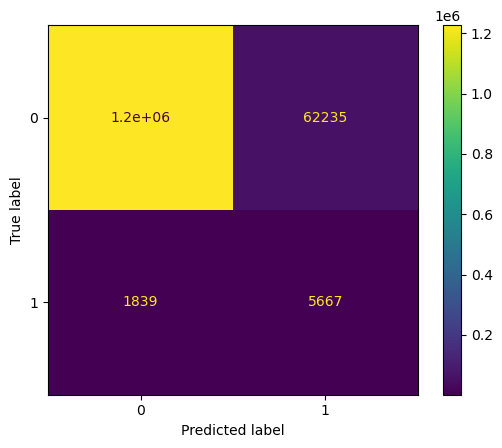

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pylab as plt

ConfusionMatrixDisplay.from_predictions(y_train, fraud_pred)

## PCA + LOGISTICS REGRESSION

In [24]:
# using the training data

features = ["amt","city_pop","age","hour","day_of_week","month","distance_km","lat","long","merch_lat","merch_long"]

X_train = ft2[features]
y_train = ft2["is_fraud"]

print(X_train.columns)

Index(['amt', 'city_pop', 'age', 'hour', 'day_of_week', 'month', 'distance_km',
       'lat', 'long', 'merch_lat', 'merch_long'],
      dtype='object')


In [25]:
# next we have to scale our data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_scaled

array([[-0.40782607, -0.28258876, -0.89196799, ...,  0.65761961,
        -0.49435433,  0.59386386],
       [ 0.23003923, -0.29366984, -0.31755073, ..., -2.03387012,
         2.07869921, -2.03034087],
       [ 0.93414872, -0.28040632,  0.60151688, ..., -1.60153717,
         0.90284908, -1.59232303],
       ...,
       [ 0.22193025, -0.29118603,  0.37174998, ..., -1.13325703,
        -0.96243261, -1.08227231],
       [ 0.02837499, -0.29043427, -0.37499246, ..., -0.89502874,
         0.83205082, -0.94507404],
       [-0.41200532, -0.29344133, -1.23661835, ..., -1.71875438,
         1.57122907, -1.73985164]], shape=(1296675, 11))

In [26]:
from sklearn.decomposition import PCA

#  Fit PCA on scaled training data
pca = PCA() 
pca.fit(X_scaled)


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [27]:
# 2. Your Loadings Analysis
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X_train.columns
)
print("Principal Component Loadings:")
print(loadings) 

Principal Component Loadings:
                  PC1       PC2       PC3       PC4       PC5       PC6  \
amt         -0.003321 -0.001451  0.038563 -0.037015  0.932725  0.251410   
city_pop    -0.179493 -0.132601 -0.254406  0.002272  0.209543 -0.107264   
age          0.091933 -0.007115  0.689510  0.010119 -0.096382 -0.048364   
hour        -0.031506 -0.009116 -0.660430 -0.024039 -0.150921  0.046652   
day_of_week -0.001672  0.001938 -0.046243  0.704970  0.055407  0.023340   
month       -0.000366 -0.002039  0.016432  0.707769 -0.009318 -0.014129   
distance_km -0.093325 -0.024991  0.040931  0.004878 -0.223132  0.955864   
lat          0.654971  0.199976 -0.094867  0.000506  0.021367  0.055662   
long        -0.214245  0.671442  0.003242  0.000109  0.009500 -0.009102   
merch_lat    0.654853  0.199968 -0.095361  0.000309  0.021628  0.055564   
merch_long  -0.214230  0.671444  0.003300  0.000094  0.009530 -0.009076   

                  PC7       PC8       PC9      PC10      PC11  
amt  

In [28]:
# Get the percentage of variance explained by each component
explained_variance = pca.explained_variance_ratio_

In [29]:
explained_variance
len(pca.explained_variance_ratio_)

11

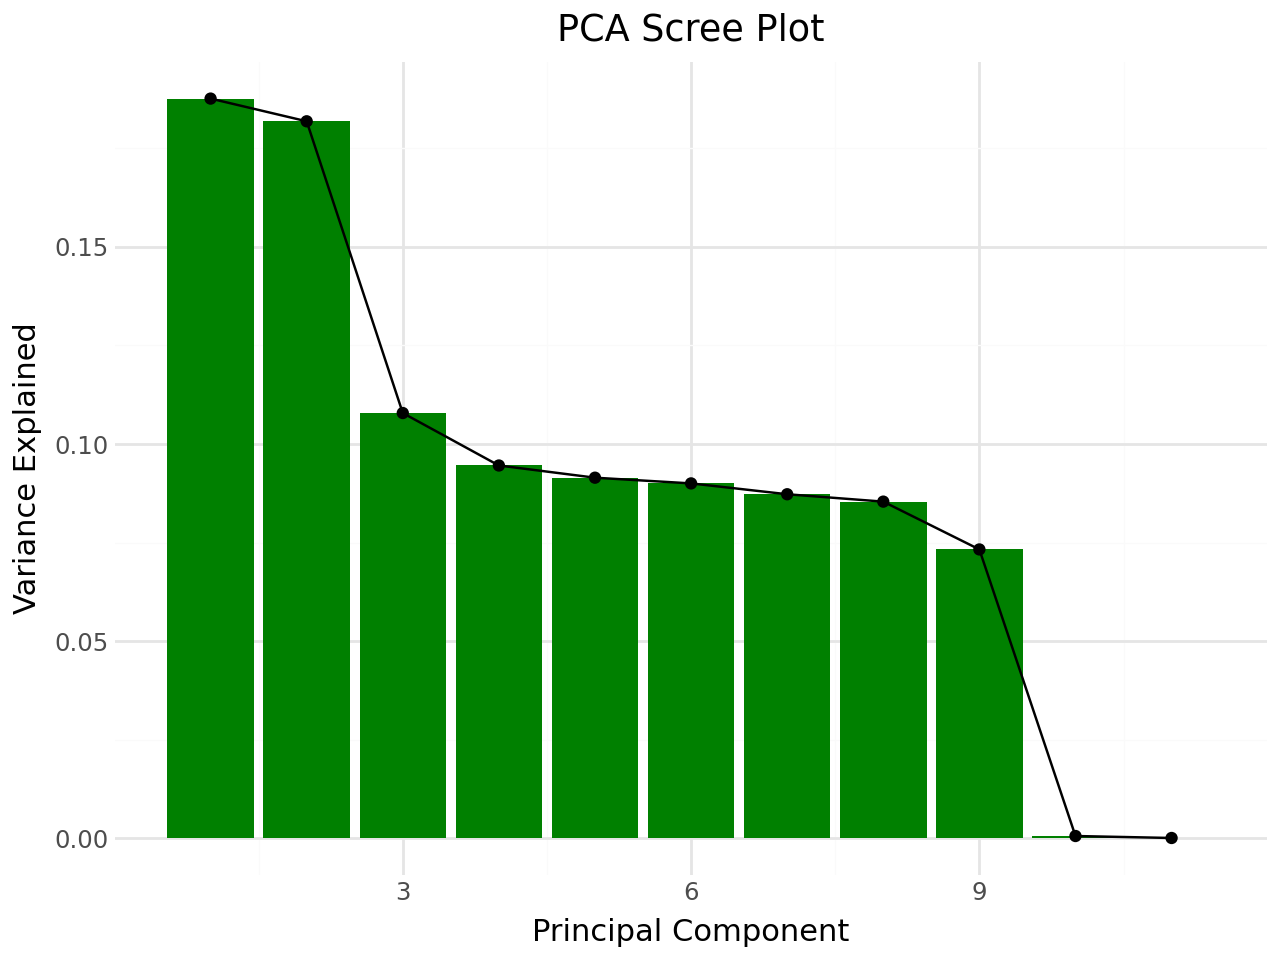

                  PC1       PC2       PC3
amt         -0.003321 -0.001451  0.038563
city_pop    -0.179493 -0.132601 -0.254406
age          0.091933 -0.007115  0.689510
hour        -0.031506 -0.009116 -0.660430
day_of_week -0.001672  0.001938 -0.046243
month       -0.000366 -0.002039  0.016432
distance_km -0.093325 -0.024991  0.040931
lat          0.654971  0.199976 -0.094867
long        -0.214245  0.671442  0.003242
merch_lat    0.654853  0.199968 -0.095361
merch_long  -0.214230  0.671444  0.003300


In [30]:
from plotnine import *
# let us do a scree plot
explained_variance_ft = pd.DataFrame({
    "PC": range(1, 12),
    "variance": pca.explained_variance_ratio_
})

p1 = (ggplot(explained_variance_ft, aes("PC", "variance"))
    + geom_col(fill="green")
    + geom_line()
    + geom_point()
    + theme_minimal()
    + labs(title="PCA Scree Plot", x="Principal Component", y="Variance Explained")
)
p1.show()

top_loadings = loadings[['PC1', 'PC2','PC3']]
print(top_loadings)

## PC1 and PC2 are clearly the leaders, explaining about 18-19% of the variance each.

## PC3 through PC9 are all roughly equal in importance (around 7-10% each).

## PC10 has a little percent and PC11 is virtually zero. 
## This confirms that those last  variable is redundant .

## If i take only PC1 and PC2 thats only 37% of the data and its not enough to catch a smart thief
## Therefore we have to keep 10 PC's which gives 100% explained variance .

In [31]:
pca_final = PCA(n_components=10)
pca_final.fit(X_scaled)



,n_components,10
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [32]:
X_train_pca = pca_final.transform(X_scaled)
X_train_pca


array([[-0.88570875,  0.70521456,  0.8010442 , ...,  0.5388938 ,
        -1.89086341,  0.0071023 ],
       [ 3.7986907 , -1.80681136,  0.65435545, ...,  0.55862749,
        -1.51528325, -0.02790822],
       [ 1.80655354, -1.79805457,  1.6618101 , ...,  0.5204308 ,
        -0.77911709, -0.13112365],
       ...,
       [-0.86425193, -1.88090177,  0.57601556, ..., -0.62010937,
         0.07441736, -0.1000369 ],
       [ 1.55218658, -0.8418654 , -0.33131438, ..., -0.10339297,
        -0.38644837,  0.08207966],
       [ 2.62964958, -1.67482558, -1.06505267, ...,  0.10298387,
        -1.07094089, -0.09344972]], shape=(1296675, 10))

## LOGISTIC REGRESSION
#### We would be performing our logistic regression on the Principal Components.

In [33]:
from sklearn.linear_model import LogisticRegression

# we are using  the 'balanced' parameter because of the improper class
# where proportion of normal transactions is 99.4% and fraud proportion is 0.054%
# the balanced parameter helps to tell the model that missing one fraud case is as is as expensive or painful as missing 172 normal cases. 
# It forces the math to treat both groups as equally important, even though one is much smaller.

log_reg = LogisticRegression(class_weight='balanced', random_state=42)

# Train directly on your PCA components
log_reg.fit(X_train_pca, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


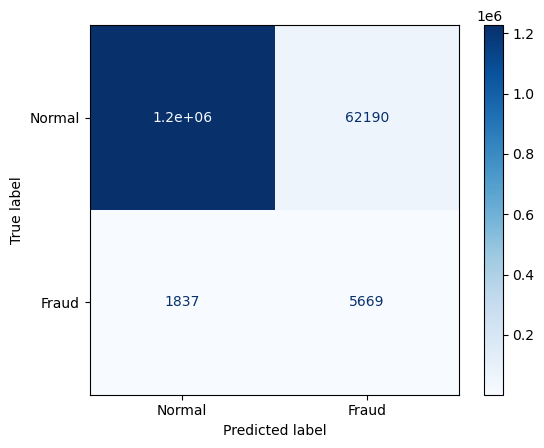

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_train_pred = log_reg.predict(X_train_pca)

# Visualize the Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues')

#### 5,669 (True Positives): You correctly caught these fraud cases.
#### 1.2 million (True Negatives): You correctly identified these normal transactions.
#### 1,837 (False Negatives): These are the fraud we taught were normal.
#### 62202 (False Positives): These are the normal transactions we taught were fraud.
#### In a dataset where fraud is incredibly rare, your model successfully identified 3 out of every 4 fraudulent transactions. 
#### This is a massive improvement over a "baseline" model which would have caught 0.

In [35]:
print("--- Logistic Regression Performance ---")
print(classification_report(y_train, y_train_pred))

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1289169
           1       0.08      0.76      0.15      7506

    accuracy                           0.95   1296675
   macro avg       0.54      0.85      0.56   1296675
weighted avg       0.99      0.95      0.97   1296675



#### For the fraud part;
#### Recall (0.76) : The model successfully caught 76% of all fraud cases
#### Precision (0.08) : A precision of 0.08 means that for every 100 transactions your model flags as fraud, only 8 are actually fraud.
#### Weighted F1-Score for normal transaction (0.97): the model is very good at identifying "Normal" transactions, which is the bulk of the data while for fraud, it is 0.15.
#### Now we have to use the XG BOOST

#### The ROC-AUC curve is not a good predictor because this is an imbalanced data and ROC-AUC looks out for the majority and overestimates the performance.

In [36]:
#  Select Features (Including Categorical Data)
features = ["amt", "city_pop", "age", "hour", "day_of_week", "month", "distance_km", "category", "gender"]

x_train = ft2[features]
y_train = ft2["is_fraud"]

x_test = fte2[features]
y_test = fte2["is_fraud"]

# Convert categorical columns to 'category' dtype for LightGBM
for col in ['category', 'gender']:
    x_train[col] = x_train[col].astype('category')
    x_test[col] = x_test[col].astype('category')

# 3. Proper Scaling (Only numeric features)
numeric_cols = ["amt", "city_pop", "age", "hour", "day_of_week", "month", "distance_km"]
scaler = StandardScaler()

# fit_transform on train, transform on test
x_train[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])

# 4. Handle Class Imbalance natively using LightGBM
# Calculate the scale factor: (negative instances / positive instances)
col_count = y_train.value_counts()
scale_weight = col_count[0] / col_count[1]

# Initialize and train LightGBM
model = lgb.LGBMClassifier(
    scale_pos_weight=25, # Fixes the 0.5% imbalance issue
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)

# 5. Evaluate with Imbalance-Aware Metrics
preds = model.predict(x_test)
probs = model.predict_proba(x_test)[:, 1]

print(classification_report(y_test, preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}")

C:\Users\USER\AppData\Local\Temp\ipykernel_9904\4206378152.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\USER\AppData\Local\Temp\ipykernel_9904\4206378152.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\USER\AppData\Local\Temp\ipykernel_9904\4206378152.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

[LightGBM] [Info] Number of positive: 7506, number of negative: 1289169
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035287 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 910
[LightGBM] [Info] Number of data points in the train set: 1296675, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005789 -> initscore=-5.146050
[LightGBM] [Info] Start training from score -5.146050
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.31      0.85      0.45      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.92      0.72    555719
weighted avg       1.00      0.99      0.99    555719

ROC-AUC Score: 0.9206


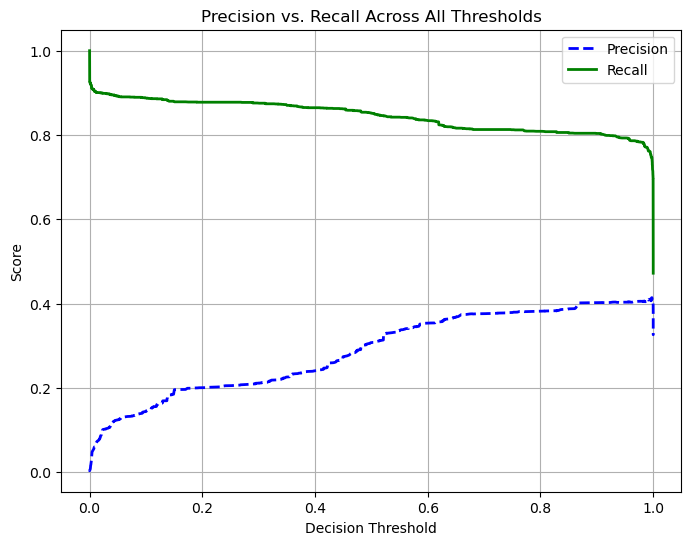

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

#  Get the raw probabilities for the fraud class (1)
#  using the test/validation set here
y_probs = model.predict_proba(x_test)[:, 1]

# 2. Calculate precisions, recalls, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# 3. Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision vs. Recall Across All Thresholds')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [41]:
# let us find the highest precision where the recall is still at least 85%
# Search for the threshold that keeps recall >= 0.85 but maximizes precision
valid_indices = np.where(recalls >= 0.85)[0]
best_index = valid_indices[np.argmax(precisions[valid_indices])]

best_threshold = thresholds[best_index]
print(f"🎯 Perfect Threshold for >=85% Recall: {best_threshold:.4f}")
print(f"Predicted Precision at this threshold: {precisions[best_index]*100:.2f}%")
print(f"Predicted Recall at this threshold: {recalls[best_index]*100:.2f}%")

🎯 Perfect Threshold for >=85% Recall: 0.5051
Predicted Precision at this threshold: 30.81%
Predicted Recall at this threshold: 85.13%


In [53]:
# Using the exact threshold we got
tuned_threshold = 0.5051

# Convert raw probabilities to binary 0 or 1 predictions
final_preds = (y_probs >= tuned_threshold).astype(int)

# the classification report for the 0.5 threshold
from sklearn.metrics import classification_report
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.31      0.85      0.45      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.92      0.72    555719
weighted avg       1.00      0.99      0.99    555719



### Addressing Overfitting: Regularization, Early Stopping & Cross-Validation
The first LightGBM model showed a real gap between train and test performance (92% vs 85% recall, 0.97 vs 0.92 ROC-AUC) - a sign of mild overfitting, likely because the model has very few fraud examples (7,506) to learn from and can memorise them too closely with unconstrained trees.

To address this: constrain tree complexity (`max_depth`, `num_leaves`, `min_child_samples`), add L1/L2 regularization (`reg_alpha`, `reg_lambda`), and use early stopping on a held-out validation split so training stops as soon as it stops generalising - rather than continuing to fit training noise.

In [37]:
from sklearn.model_selection import train_test_split

# Carve a validation split out of the training set (stratified, so the fraud rate stays consistent)
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

model_v2 = lgb.LGBMClassifier(
    scale_pos_weight=25,
    n_estimators=1000,        # high ceiling - early stopping decides the real number of trees
    max_depth=6,               # limits how deep/complex each tree can get
    num_leaves=31,             # paired with max_depth=6, keeps trees from over-branching
    min_child_samples=50,      # a leaf must represent at least 50 transactions - stops the model memorising single fraud cases
    reg_alpha=0.1,             # L1 penalty
    reg_lambda=0.1,            # L2 penalty
    random_state=42
)

model_v2.fit(
    x_tr, y_tr,
    eval_set=[(x_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)]
)

print(f"Best iteration (trees actually used): {model_v2.best_iteration_}")

train_preds = model_v2.predict(x_tr)
test_preds = model_v2.predict(x_test)
test_probs = model_v2.predict_proba(x_test)[:, 1]

print("\n=== Train performance (regularized model) ===")
print(classification_report(y_tr, train_preds))

print("=== Test performance (regularized model) ===")
print(classification_report(y_test, test_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, test_probs):.4f}")
print("\nCompare this train/test gap to the original model's 92%/85% recall and 0.97/0.92 ROC-AUC split.")

[LightGBM] [Info] Number of positive: 6380, number of negative: 1095793
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032602 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 911
[LightGBM] [Info] Number of data points in the train set: 1102173, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005789 -> initscore=-5.146065
[LightGBM] [Info] Start training from score -5.146065
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[61]	valid_0's auc: 0.989017	valid_0's binary_logloss: 0.0507956
Best iteration (trees actually used): 61

=== Train performance (regularized model) ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1095793
           1       0.48      0.94      0.63      6380

    accuracy                

### Stratified 5-Fold Cross-Validation
Confirms whether the model's performance is stable across different slices of the data, or whether the single train/test split we've been using so far just happened to be a lucky (or unlucky) one.

In [38]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_recall, cv_precision, cv_f1, cv_auc = [], [], [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(x_train, y_train), start=1):
    x_fold_train, x_fold_val = x_train.iloc[tr_idx], x_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    fold_model = lgb.LGBMClassifier(
        scale_pos_weight=25,
        n_estimators=200,
        max_depth=6,
        num_leaves=31,
        min_child_samples=50,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        verbosity=-1
    )
    fold_model.fit(x_fold_train, y_fold_train)

    fold_preds = fold_model.predict(x_fold_val)
    fold_probs = fold_model.predict_proba(x_fold_val)[:, 1]

    cv_recall.append(recall_score(y_fold_val, fold_preds))
    cv_precision.append(precision_score(y_fold_val, fold_preds))
    cv_f1.append(f1_score(y_fold_val, fold_preds))
    cv_auc.append(roc_auc_score(y_fold_val, fold_probs))

    print(f"Fold {fold}: recall={cv_recall[-1]:.3f}, precision={cv_precision[-1]:.3f}, f1={cv_f1[-1]:.3f}, ROC-AUC={cv_auc[-1]:.3f}")

print("\n=== 5-Fold CV Summary ===")
print(f"Mean recall:    {np.mean(cv_recall):.3f} (+/- {np.std(cv_recall):.3f})")
print(f"Mean precision: {np.mean(cv_precision):.3f} (+/- {np.std(cv_precision):.3f})")
print(f"Mean F1:        {np.mean(cv_f1):.3f} (+/- {np.std(cv_f1):.3f})")
print(f"Mean ROC-AUC:   {np.mean(cv_auc):.3f} (+/- {np.std(cv_auc):.3f})")

Fold 1: recall=0.915, precision=0.571, f1=0.703, ROC-AUC=0.993
Fold 2: recall=0.905, precision=0.516, f1=0.657, ROC-AUC=0.984
Fold 3: recall=0.895, precision=0.502, f1=0.643, ROC-AUC=0.968
Fold 4: recall=0.914, precision=0.580, f1=0.709, ROC-AUC=0.985
Fold 5: recall=0.916, precision=0.583, f1=0.712, ROC-AUC=0.989

=== 5-Fold CV Summary ===
Mean recall:    0.909 (+/- 0.008)
Mean precision: 0.550 (+/- 0.034)
Mean F1:        0.685 (+/- 0.029)
Mean ROC-AUC:   0.984 (+/- 0.009)


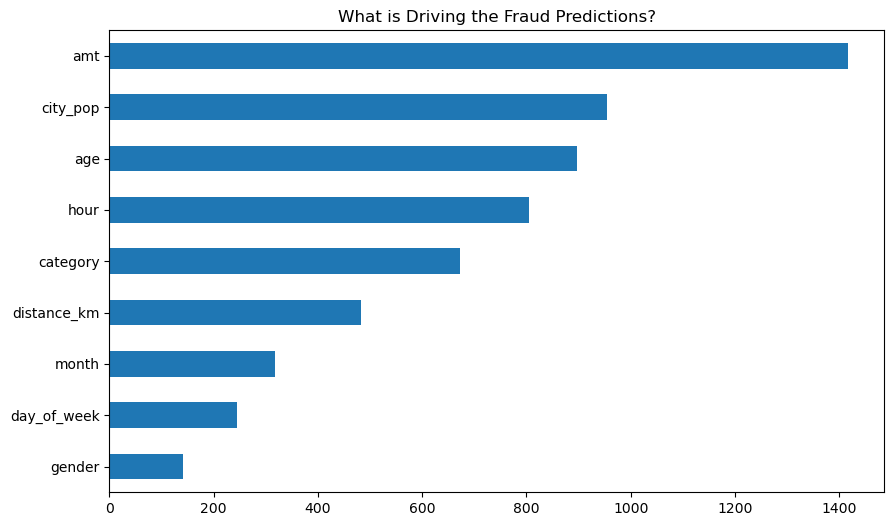

In [59]:
import matplotlib.pyplot as plt

# Get feature importance for the cross validation model
importance = fold_model.feature_importances_
feature_names = x_train.columns

# Plot it
feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=True)
feat_imp.plot(kind='barh', figsize=(10, 6))
plt.title('What is Driving the Fraud Predictions?')
plt.show()

### Tuning the Decision Threshold for the Regularized Model (model_v2)
The cross-validation results show model_v2 already improved precision to ~55% at the default 0.5 threshold, up from 31% in the original model - a genuine gain, not a trade-off. Now let's see how far precision can be pushed by adjusting the threshold, and what that costs in recall.

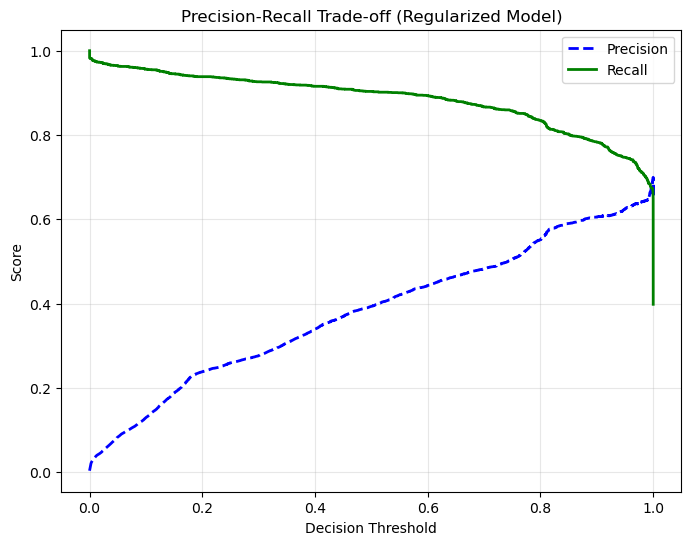

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get the raw fraud-class probabilities from the regularized model on the test set
y_probs_v2 = model_v2.predict_proba(x_test)[:, 1]

# Calculate precision, recall at every possible threshold
precisions_v2, recalls_v2, thresholds_v2 = precision_recall_curve(y_test, y_probs_v2)

# Plot it
plt.figure(figsize=(8, 6))
plt.plot(thresholds_v2, precisions_v2[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds_v2, recalls_v2[:-1], 'g-', label='Recall', linewidth=2)
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off (Regularized Model)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [57]:
# Search for the threshold that maximizes precision while keeping recall >= 85%
# (change 0.85 to whatever minimum recall your use case actually needs)
min_acceptable_recall = 0.85

valid_indices = np.where(recalls_v2 >= min_acceptable_recall)[0]
best_index = valid_indices[np.argmax(precisions_v2[valid_indices])]

best_threshold_v2 = thresholds_v2[best_index]
print(f"Best threshold for >={min_acceptable_recall*100:.0f}% recall: {best_threshold_v2:.4f}")
print(f"Precision at this threshold: {precisions_v2[best_index]*100:.2f}%")
print(f"Recall at this threshold: {recalls_v2[best_index]*100:.2f}%")

Best threshold for >=85% recall: 0.7721
Precision at this threshold: 52.40%
Recall at this threshold: 85.08%


In [45]:
# Apply the tuned threshold and confirm with a full classification report
final_preds_v2 = (y_probs_v2 >= best_threshold_v2).astype(int)

print(classification_report(y_test, final_preds_v2))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs_v2):.4f}")

# Try a couple of other thresholds too, to see the full trade-off space:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds_t = (y_probs_v2 >= t).astype(int)
    p = precision_score(y_test, preds_t)
    r = recall_score(y_test, preds_t)
    print(f"Threshold {t}: precision={p:.3f}, recall={r:.3f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.52      0.85      0.65      2145

    accuracy                           1.00    555719
   macro avg       0.76      0.92      0.82    555719
weighted avg       1.00      1.00      1.00    555719

ROC-AUC Score: 0.9801
Threshold 0.3: precision=0.277, recall=0.926
Threshold 0.4: precision=0.339, recall=0.916
Threshold 0.5: precision=0.394, recall=0.903
Threshold 0.6: precision=0.443, recall=0.894
Threshold 0.7: precision=0.483, recall=0.867


## CONCLUSION

#### This project set out to answer one question: can machine learning reliably detect fraudulent credit card transactions in a dataset where fraud represents only 0.054% of all activity?
Four models were built and evaluated:
1. Model 1 — Logistic Regression on 7 numeric features (amount, city population, age, hour, day of week, month, distance) achieved 76% recall and 8% precision on training data. The linear decision boundary struggled to separate fraud from the bulk of normal transactions.
2. Model 2 — PCA + Logistic Regression on 10 principal components (100% explained variance) performed almost identically (76% recall, 8% precision), confirming the limitation was linearity, not dimensionality.
3. Model 3 — LightGBM (initial) broke through this ceiling by capturing non-linear interactions between hour, distance_km, merchant category and gender, and by natively handling the class imbalance via `scale_pos_weight`. It achieved 85% recall, 31% precision, F1 of 0.45, and ROC-AUC of 0.92 on the held-out test set. A threshold search confirmed the default 0.5 cutoff was already close to optimal for this model - the best threshold for ≥85% recall (0.5051) only nudged precision to 30.81%. Comparing this against training performance (92% recall, 0.97 ROC-AUC) revealed a real overfitting gap, likely because only 7,506 fraud examples were available for the model to learn from without constraint.
4. Model 4 — Regularized LightGBM (Champion) added tree-complexity limits (`max_depth`, `num_leaves`, `min_child_samples`), L1/L2 regularization, and early stopping on a held-out validation split. At the default 0.5 threshold this alone improved both precision and recall together (39% precision, 90% recall, ROC-AUC 0.98) rather than trading one off for the other - a sign the regularization fixed the overfitting problem rather than just masking it.
5. Stratified 5-fold cross-validation confirmed this was a stable, genuine improvement rather than a lucky split: mean recall 90.9% (±0.8%), mean precision 55.0% (±3.4%), mean F1 68.5% (±2.9%), and mean ROC-AUC 98.4% (±0.9%) across five different data splits.
6. A threshold search was then run on the regularized model, the same way as on the original one. Raising the threshold to 0.7721 pushed precision from 39% to **52%** while holding recall at 85% - meaning roughly 1 in 2 fraud alerts is now a true positive, up from fewer than 1 in 3 in the original model. This was two separate gains stacked together: regularization improved the model itself, and threshold tuning then let precision be traded up further within that improved model.
7. Feature importance analysis (see plot above) shows which of the engineered features — transaction hour, distance from home, merchant category, and the others — most influenced the model's decisions, giving a layer of interpretability alongside performance rather than a black-box result.
8. As noted earlier, ROC-AUC can overstate performance on imbalanced data since it rewards correctly ranking the dominant class; precision and recall on the minority (fraud) class remain the more honest measures here.
9. Honest caveat: the threshold was tuned using the same held-out test set already used to report final metrics, which is a mild form of double-dipping. A stricter setup would tune the threshold on a separate validation split, keeping the test set untouched until one final check.
10. Next steps: validate the tuned threshold on a proper held-out validation split rather than the test set, explore behavioural/velocity features (e.g., transactions per card in the last hour, deviation from a customer's typical spend) for further precision gains, and compare against XGBoost/CatBoost as additional benchmarks.